# Load and Understand the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("upi_daily_statistics.csv")

In [5]:
df.head()

,Day,Volume (In Mn.),Value (In Cr.)
0,01-May-21,86.239,18140.21
1,02-May-21,79.373,13692.47
2,03-May-21,87.717,20191.07
3,04-May-21,89.311,20005.02
4,05-May-21,87.704,19438.15


In [7]:
df.tail()

,Day,Volume (In Mn.),Value (In Cr.)
1913,27-Jul-26,741.09,90954.66
1914,28-Jul-26,730.07,87253.63
1915,29-Jul-26,741.25,88600.32
1916,30-Jul-26,732.33,92466.43
1917,31-Jul-26,770.20,112791.68


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1918 entries, 0 to 1917
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Day              1918 non-null   object 
 1   Volume (In Mn.)  1918 non-null   float64
 2   Value (In Cr.)   1918 non-null   float64
dtypes: float64(2), object(1)
memory usage: 45.1+ KB


In [11]:
df.describe()

,Volume (In Mn.),Value (In Cr.)
count,1918.000000,1918.000000
mean,405.429205,57911.162246
std,208.942508,25780.579209
min,71.283000,9669.180000
25%,214.469500,36045.482500
50%,387.702500,56805.105000
75%,590.990250,77392.915000
max,809.690000,131735.460000


In [13]:
# Convert Day to datetime
df['Day'] = pd.to_datetime(df['Day'], format='%d-%b-%y')

In [17]:
df.dtypes

Day                datetime64[ns]
Volume (In Mn.)           float64
Value (In Cr.)            float64
dtype: object

In [19]:
# Set Day as the index
df = df.set_index('Day')

In [21]:
df.tail()

,Volume (In Mn.),Value (In Cr.)
Day,,
2026-07-27,741.09,90954.66
2026-07-28,730.07,87253.63
2026-07-29,741.25,88600.32
2026-07-30,732.33,92466.43
2026-07-31,770.20,112791.68


# Explore the Time Series

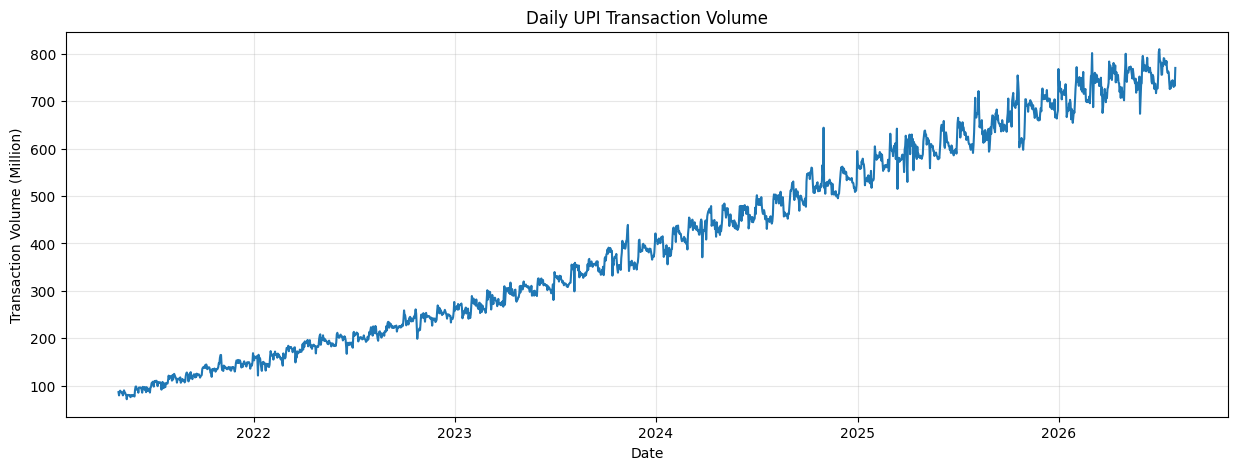

In [25]:
plt.figure(figsize=(15, 5))

plt.plot(df.index, df['Volume (In Mn.)'])

plt.title('Daily UPI Transaction Volume')
plt.xlabel('Date')
plt.ylabel('Transaction Volume (Million)')
plt.grid(alpha=0.3)

plt.show()

The UPI transaction volume exhibits a strong upward trend accompanied by recurring short-term fluctuations. The increasing magnitude of fluctuations over time suggests non-constant variance, while several extreme spikes indicate potential outlier or event effects.

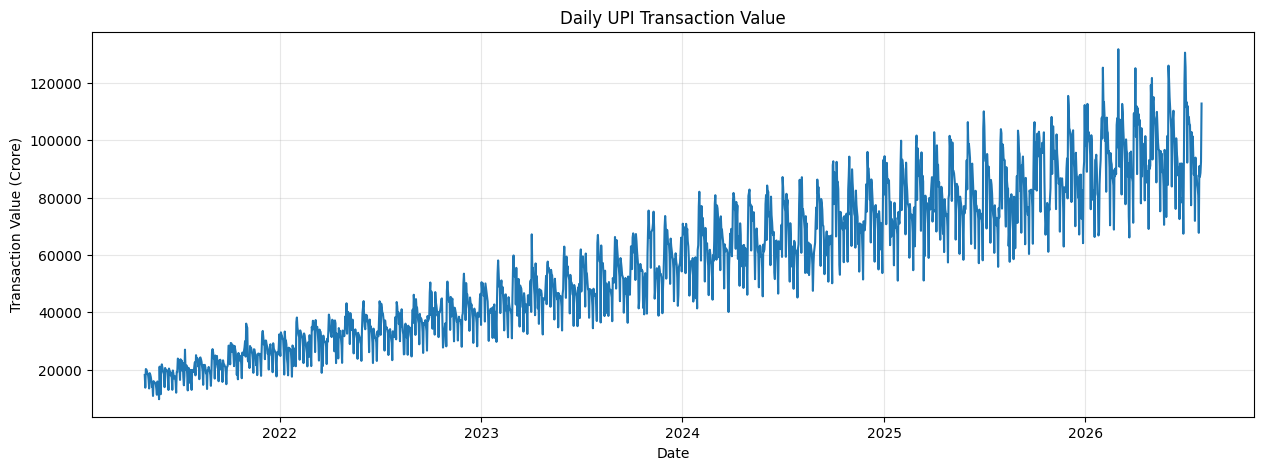

In [28]:
plt.figure(figsize=(15, 5))

plt.plot(df.index, df['Value (In Cr.)'])

plt.title('Daily UPI Transaction Value')
plt.xlabel('Date')
plt.ylabel('Transaction Value (Crore)')
plt.grid(alpha=0.3)

plt.show()

The time series shows a strong upward trend in daily UPI transaction value, along with recurring short-term fluctuations. The magnitude of these fluctuations increases over time, indicating non-constant variance and possible seasonal effects.

# Decompose the Volume series

In [32]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [34]:
decomposition = seasonal_decompose(
    df['Volume (In Mn.)'],
    model='additive',
    period=7
)

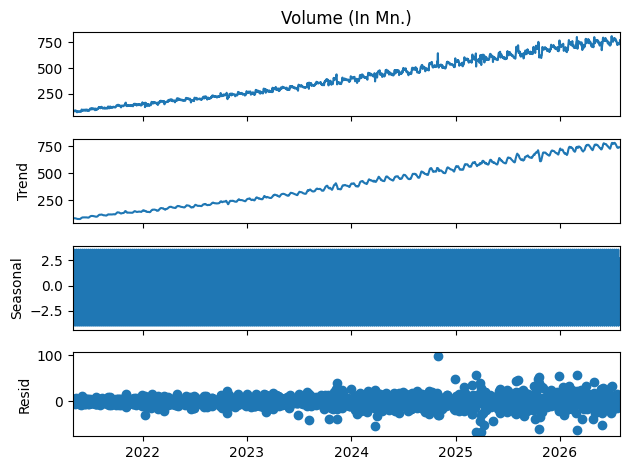

In [36]:
decomposition.plot()
plt.show()

The decomposition reveals a strong upward trend and a recurring weekly seasonal pattern in UPI transaction volume. The residual component contains irregular fluctuations and several notable spikes, with increasing variability over time.

### Autocorrelation

In [40]:
from statsmodels.graphics.tsaplots import plot_acf

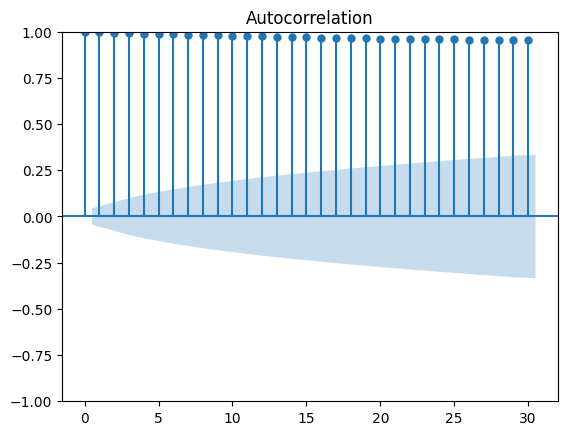

In [42]:
plot_acf(df['Volume (In Mn.)'], lags=30)

plt.show()

This ACF plot does not let us confidently identify weekly seasonality yet.

The main issue is that the autocorrelation is very high at almost every lag, which is expected when the series has such a strong upward trend. The trend is dominating the ACF.

We need to remove the trend first and then calculate the ACF.

In [46]:
df['Volume_diff'] = df['Volume (In Mn.)'].diff()

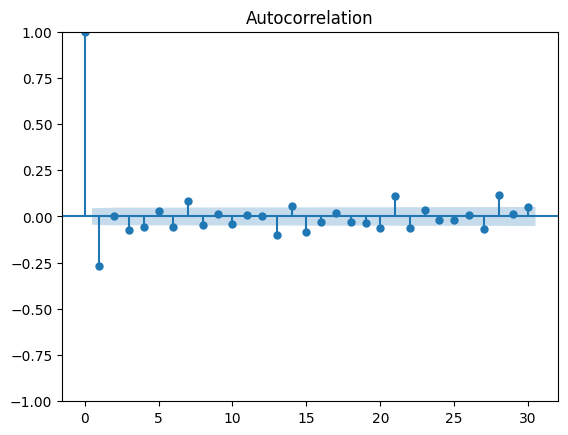

In [48]:
plot_acf(df['Volume_diff'].dropna(), lags=30)

plt.show()

### Autocorrelation Analysis

After first-order differencing, significant autocorrelation is observed at lags 7, 14, 21 and 28, indicating a recurring weekly seasonal pattern in UPI transaction volume.

Let's quantify the weekly seasonality using the seasonal strength measure.

In [52]:
seasonal_strength = 1 - (
    decomposition.resid.var() /
    (decomposition.resid + decomposition.seasonal).var()
)

seasonal_strength

0.05130418766891376

The ACF indicates a statistically significant weekly pattern, although the estimated seasonal strength is relatively low (0.051), suggesting that weekly seasonality contributes only modestly to the overall variation.

## Check whether a log transformation is appropriate

From the plots, the variability increases as transaction volume increases. A common way to stabilize this is a log transformation.

In [57]:
df['Volume_log'] = np.log(df['Volume (In Mn.)'])

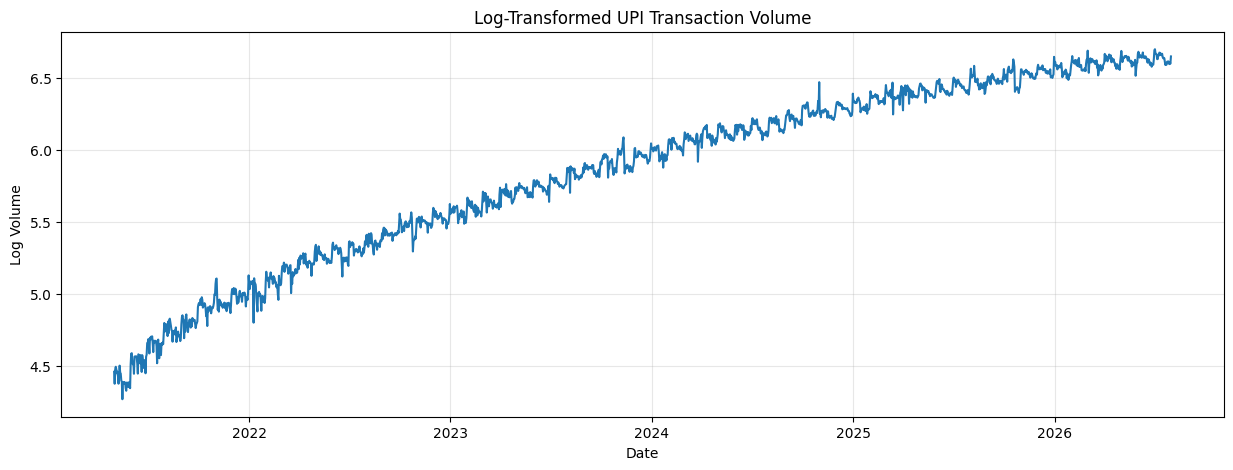

In [61]:
plt.figure(figsize=(15, 5))

plt.plot(df.index, df['Volume_log'])

plt.title('Log-Transformed UPI Transaction Volume')
plt.xlabel('Date')
plt.ylabel('Log Volume')
plt.grid(alpha=0.3)

plt.show()

The log transformation reduces the increasing variability observed in the original volume series, making the variance more stable across time. The underlying upward trend remains present.

## Test for Stationarity

We'll use the Augmented Dickey-Fuller (ADF) test on the log-transformed series.

In [68]:
from statsmodels.tsa.stattools import adfuller

In [70]:
adf_result = adfuller(df['Volume_log'].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -6.099287080222306
p-value: 9.925050926929778e-08


Since the p-value is far below 0.05, we reject the null hypothesis of a unit root.

So, according to the ADF test, the log-transformed series is stationary.

However, visually we still have a clear trend. So before deciding that no differencing is needed, we should verify this with another stationarity test.

In [73]:
#Run the KPSS test
from statsmodels.tsa.stattools import kpss

kpss_result = kpss(df['Volume_log'].dropna(), regression='c')

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

KPSS Statistic: 6.707928236636785
p-value: 0.01


C:\Users\Soham Sarkar\AppData\Local\Temp\ipykernel_18088\1177294370.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(df['Volume_log'].dropna(), regression='c')


For KPSS, the null hypothesis is stationarity.

Since p < 0.05, we reject the null hypothesis. KPSS says non-stationary

We have conflicting results. This can happen because the log series still has a strong deterministic trend.

In [77]:
# Difference the log-transformed series
df['Volume_log_diff'] = df['Volume_log'].diff()

In [79]:
adf_result = adfuller(df['Volume_log_diff'].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -21.039065648811654
p-value: 0.0


In [81]:
kpss_result = kpss(df['Volume_log_diff'].dropna(), regression='c')

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

KPSS Statistic: 0.39740924546981077
p-value: 0.07827187695266777


### Stationarity Test Results

After applying a log transformation and first-order differencing, both ADF and KPSS tests indicate that the series is stationary. Therefore, the transformed series is suitable for ARIMA-type modelling.

# Plot the ACF of the stationary series

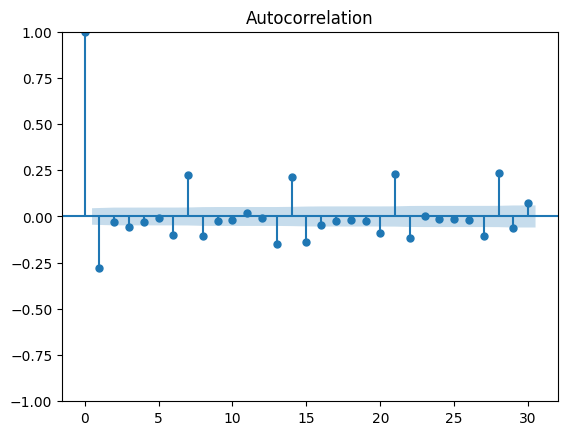

In [91]:
plot_acf(df['Volume_log_diff'].dropna(), lags=30)

plt.show()

The ACF of the stationary series shows significant autocorrelation at lag 1 and recurring positive spikes at lags 7, 14, 21 and 28, indicating a weekly seasonal component.

## PACF

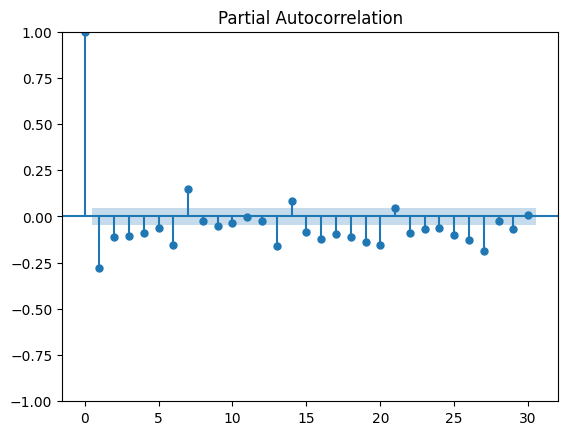

In [93]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df['Volume_log_diff'].dropna(), lags=30)

plt.show()

The PACF shows a strong negative spike at lag 1, while most other lags are relatively small, with some seasonal spikes around 7 and 14.

# Train Test Split

In [104]:
train = df['Volume_log'][:-30]
test = df['Volume_log'][-30:]

In [106]:
print("Train size:", len(train))
print("Test size:", len(test))

Train size: 1888
Test size: 30


## ARIMA (1,1,1)

In [109]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(1, 1, 1))
arima_result = arima_model.fit()

C:\Users\Soham Sarkar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Soham Sarkar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Soham Sarkar\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [111]:
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:             Volume_log   No. Observations:                 1888
Model:                 ARIMA(1, 1, 1)   Log Likelihood                3561.235
Date:                Sun, 09 Aug 2026   AIC                          -7116.470
Time:                        11:23:20   BIC                          -7099.842
Sample:                    05-01-2021   HQIC                         -7110.347
                         - 07-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3993      0.035     11.453      0.000       0.331       0.468
ma.L1         -0.7205      0.033    -22.057      0.000      -0.785      -0.656
sigma2         0.0013   2.45e-05     54.762      0.0

In [113]:
arima_forecast = arima_result.forecast(steps=30)

In [115]:
print(arima_forecast)

2026-07-02    6.661698
2026-07-03    6.650601
2026-07-04    6.646169
2026-07-05    6.644400
2026-07-06    6.643693
2026-07-07    6.643411
2026-07-08    6.643298
2026-07-09    6.643253
2026-07-10    6.643235
2026-07-11    6.643228
2026-07-12    6.643225
2026-07-13    6.643224
2026-07-14    6.643224
2026-07-15    6.643223
2026-07-16    6.643223
2026-07-17    6.643223
2026-07-18    6.643223
2026-07-19    6.643223
2026-07-20    6.643223
2026-07-21    6.643223
2026-07-22    6.643223
2026-07-23    6.643223
2026-07-24    6.643223
2026-07-25    6.643223
2026-07-26    6.643223
2026-07-27    6.643223
2026-07-28    6.643223
2026-07-29    6.643223
2026-07-30    6.643223
2026-07-31    6.643223
Freq: D, Name: predicted_mean, dtype: float64


In [117]:
arima_forecast_volume = np.exp(arima_forecast)
arima_forecast_volume

2026-07-02    781.877530
2026-07-03    773.248860
2026-07-04    769.829802
2026-07-05    768.468683
2026-07-06    767.925814
2026-07-07    767.709135
2026-07-08    767.622625
2026-07-09    767.588082
2026-07-10    767.574287
2026-07-11    767.568779
2026-07-12    767.566579
2026-07-13    767.565701
2026-07-14    767.565350
2026-07-15    767.565210
2026-07-16    767.565154
2026-07-17    767.565132
2026-07-18    767.565123
2026-07-19    767.565119
2026-07-20    767.565118
2026-07-21    767.565117
2026-07-22    767.565117
2026-07-23    767.565117
2026-07-24    767.565117
2026-07-25    767.565117
2026-07-26    767.565117
2026-07-27    767.565117
2026-07-28    767.565117
2026-07-29    767.565117
2026-07-30    767.565117
2026-07-31    767.565117
Freq: D, Name: predicted_mean, dtype: float64

In [121]:
test_volume = np.exp(test)

In [125]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test_volume, arima_forecast_volume)
rmse = np.sqrt(mean_squared_error(test_volume, arima_forecast_volume))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 19.144172042213018
RMSE: 22.221763473772878


The baseline ARIMA(1,1,1) model achieved an MAE of 19.14 million and an RMSE of 22.22 million transactions per day on the 30-day test set.

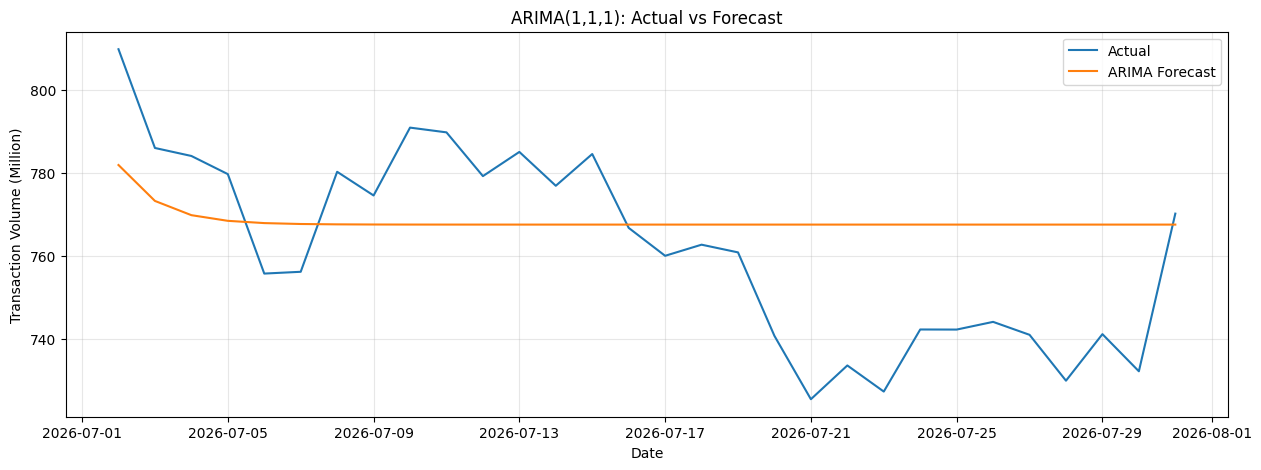

In [128]:
plt.figure(figsize=(15, 5))

plt.plot(test_volume.index, test_volume, label='Actual')
plt.plot(arima_forecast_volume.index, arima_forecast_volume, label='ARIMA Forecast')

plt.title('ARIMA(1,1,1): Actual vs Forecast')
plt.xlabel('Date')
plt.ylabel('Transaction Volume (Million)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# SARIMA (2,0,3)(3,1,1,30)

In [131]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [239]:
sarima_model = SARIMAX(
    train,
    order=(2, 0, 3),
    seasonal_order=(3, 1, 1, 30)
)

In [241]:
sarima_result = sarima_model.fit()

In [242]:
print(sarima_result.summary())

                                      SARIMAX Results                                       
Dep. Variable:                           Volume_log   No. Observations:                 1888
Model:             SARIMAX(2, 0, 3)x(3, 1, [1], 30)   Log Likelihood                3397.265
Date:                              Sun, 09 Aug 2026   AIC                          -6774.530
Time:                                      13:10:43   BIC                          -6719.258
Sample:                                  05-01-2021   HQIC                         -6754.160
                                       - 07-01-2026                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0527      0.009      5.971      0.000       0.035       0.070
ar.L2          0.94

In [245]:
sarima_forecast = sarima_result.forecast(steps=30)
sarima_forecast.head()

2026-07-02    6.671941
2026-07-03    6.663805
2026-07-04    6.652749
2026-07-05    6.660485
2026-07-06    6.654677
Freq: D, Name: predicted_mean, dtype: float64

In [247]:
sarima_forecast_volume = np.exp(sarima_forecast)
sarima_forecast_volume.head()

2026-07-02    789.927367
2026-07-03    783.526607
2026-07-04    774.911560
2026-07-05    780.929726
2026-07-06    776.406817
Freq: D, Name: predicted_mean, dtype: float64

In [249]:
mae_sarima = mean_absolute_error(test_volume, sarima_forecast_volume)
rmse_sarima = np.sqrt(mean_squared_error(test_volume, sarima_forecast_volume))

print("SARIMA MAE:", mae_sarima)
print("SARIMA RMSE:", rmse_sarima)

SARIMA MAE: 11.63353690147148
SARIMA RMSE: 15.78989000145515


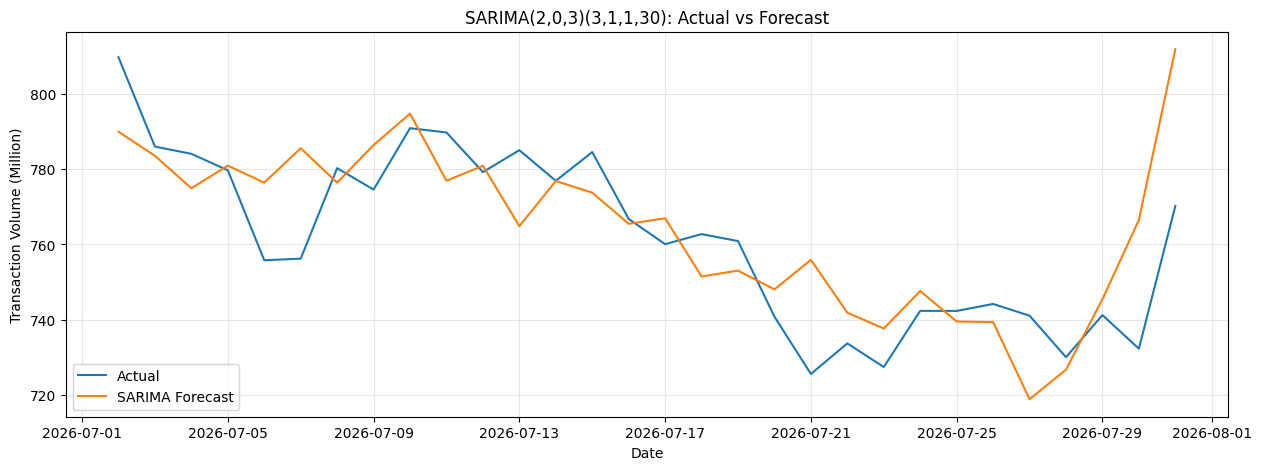

In [255]:
plt.figure(figsize=(15, 5))

plt.plot(test_volume.index, test_volume, label='Actual')
plt.plot(
    sarima_forecast_volume.index,
    sarima_forecast_volume,
    label='SARIMA Forecast'
)

plt.title('SARIMA(2,0,3)(3,1,1,30): Actual vs Forecast')
plt.xlabel('Date')
plt.ylabel('Transaction Volume (Million)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [253]:
from sklearn.metrics import mean_absolute_percentage_error

mape_arima = mean_absolute_percentage_error(
    test_volume,
    arima_forecast_volume
) * 100

mape_sarima = mean_absolute_percentage_error(
    test_volume,
    sarima_forecast_volume
) * 100

print("ARIMA MAPE:", mape_arima)
print("SARIMA MAPE:", mape_sarima)

ARIMA MAPE: 2.5409931727226476
SARIMA MAPE: 1.5343678140524322


## Final model evaluation

In [258]:
# Combine training + validation data
final_train = df['Volume_log'][:-30]

print("Final training size:", len(final_train))
print("Test size:", len(test))

Final training size: 1888
Test size: 30


In [260]:
final_sarima_model = SARIMAX(
    final_train,
    order=(2, 0, 3),
    seasonal_order=(3, 1, 1, 30)
)

final_sarima_result = final_sarima_model.fit(
    method_kwargs={"maxiter": 200}
)

print(final_sarima_result.summary())

C:\Users\Soham Sarkar\anaconda3\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: method_kwargs. After release 0.14, this will raise.
  warnings.warn(


                                      SARIMAX Results                                       
Dep. Variable:                           Volume_log   No. Observations:                 1888
Model:             SARIMAX(2, 0, 3)x(3, 1, [1], 30)   Log Likelihood                3397.265
Date:                              Sun, 09 Aug 2026   AIC                          -6774.530
Time:                                      13:29:05   BIC                          -6719.258
Sample:                                  05-01-2021   HQIC                         -6754.160
                                       - 07-01-2026                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0527      0.009      5.971      0.000       0.035       0.070
ar.L2          0.94

In [262]:
final_forecast = final_sarima_result.forecast(
    steps=len(test)
)

# Convert back to original Volume scale
final_forecast_volume = np.exp(final_forecast)

print(final_forecast_volume)

2026-07-02    789.927367
2026-07-03    783.526607
2026-07-04    774.911560
2026-07-05    780.929726
2026-07-06    776.406817
2026-07-07    785.534276
2026-07-08    776.404987
2026-07-09    786.382453
2026-07-10    794.727059
2026-07-11    776.910555
2026-07-12    780.892584
2026-07-13    764.867180
2026-07-14    776.832915
2026-07-15    773.744558
2026-07-16    765.487632
2026-07-17    766.939214
2026-07-18    751.497842
2026-07-19    753.052557
2026-07-20    748.064731
2026-07-21    755.916636
2026-07-22    741.880493
2026-07-23    737.686615
2026-07-24    747.631843
2026-07-25    739.545270
2026-07-26    739.385566
2026-07-27    718.911643
2026-07-28    726.773260
2026-07-29    745.468504
2026-07-30    766.482255
2026-07-31    811.822399
Freq: D, Name: predicted_mean, dtype: float64


In [264]:
final_mae = mean_absolute_error(
    test_volume,
    final_forecast_volume
)

final_rmse = np.sqrt(
    mean_squared_error(
        test_volume,
        final_forecast_volume
    )
)

final_mape = mean_absolute_percentage_error(
    test_volume,
    final_forecast_volume
) * 100

print(f"Final MAE:  {final_mae:.2f} million")
print(f"Final RMSE: {final_rmse:.2f} million")
print(f"Final MAPE: {final_mape:.2f}%")

Final MAE:  11.63 million
Final RMSE: 15.79 million
Final MAPE: 1.53%


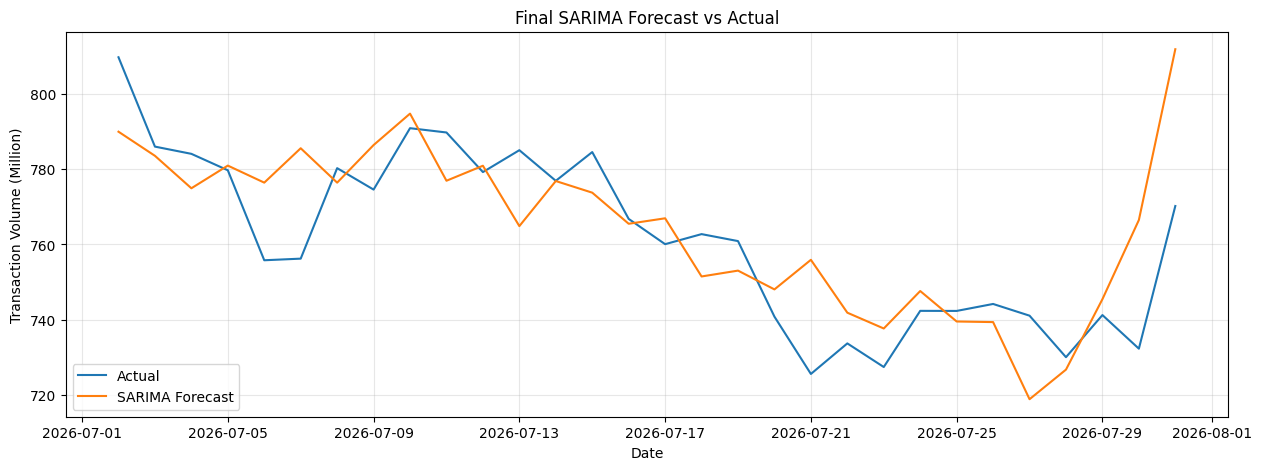

In [266]:
plt.figure(figsize=(15, 5))

plt.plot(
    test_volume.index,
    test_volume,
    label='Actual'
)

plt.plot(
    final_forecast_volume.index,
    final_forecast_volume,
    label='SARIMA Forecast'
)

plt.title('Final SARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Transaction Volume (Million)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Residual Diagnostic

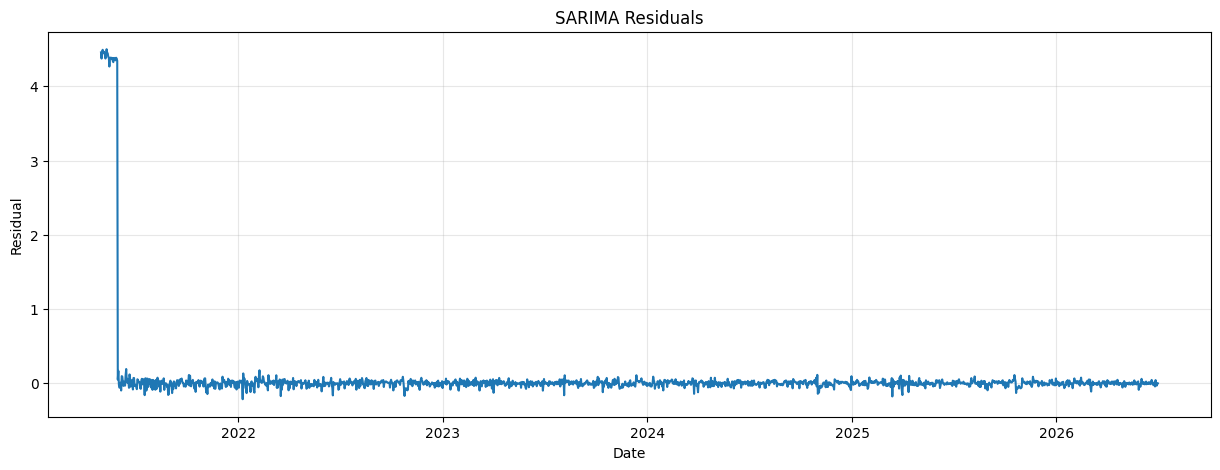

In [268]:
residuals = final_sarima_result.resid

plt.figure(figsize=(15, 5))

plt.plot(residuals)

plt.title('SARIMA Residuals')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(alpha=0.3)

plt.show()

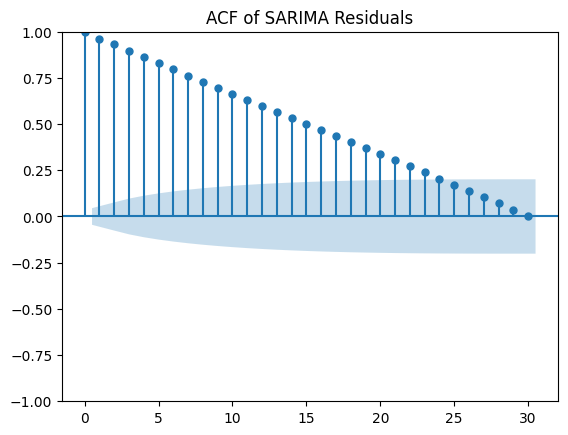

In [270]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals.dropna(), lags=30)

plt.title('ACF of SARIMA Residuals')
plt.show()

In [272]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residuals.dropna(),
    lags=[7, 14, 30],
    return_df=True
)

print(ljung_box)

         lb_stat  lb_pvalue
7    9931.935378        0.0
14  15280.834834        0.0
30  17949.570633        0.0


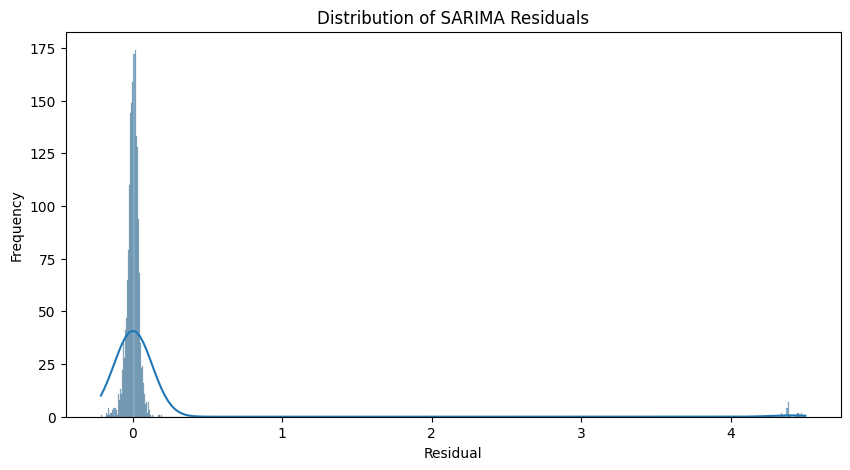

In [274]:
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    residuals.dropna(),
    kde=True
)

plt.title('Distribution of SARIMA Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')

plt.show()

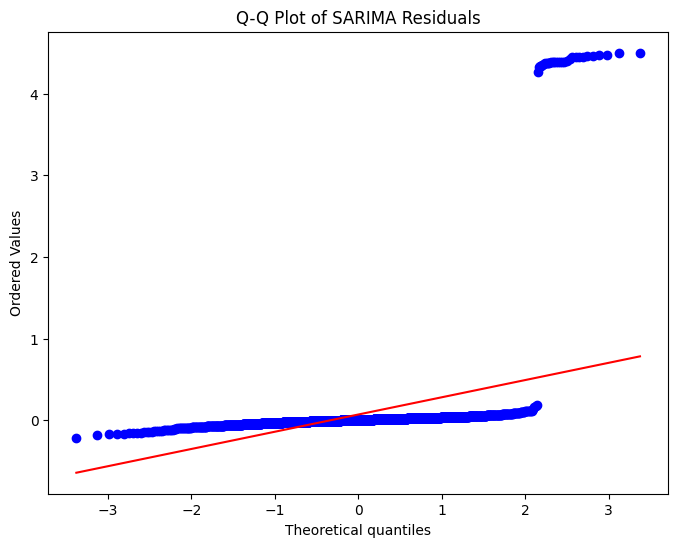

In [276]:
import scipy.stats as stats

plt.figure(figsize=(8, 6))

stats.probplot(
    residuals.dropna(),
    dist="norm",
    plot=plt
)

plt.title('Q-Q Plot of SARIMA Residuals')
plt.show()

## Final Model Comparison

In [ ]:
final_model_all = SARIMAX(
    df['Volume_log'],
    order=(2, 0, 3),
    seasonal_order=(3, 1, 1, 30)
)

final_result_all = final_model_all.fit(
    method_kwargs={"maxiter": 200}
)

future_forecast_log = final_result_all.forecast(steps=30)

# Convert back to original scale
future_forecast = np.exp(future_forecast_log)

print(future_forecast)

C:\Users\Soham Sarkar\anaconda3\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: method_kwargs. After release 0.14, this will raise.
  warnings.warn(


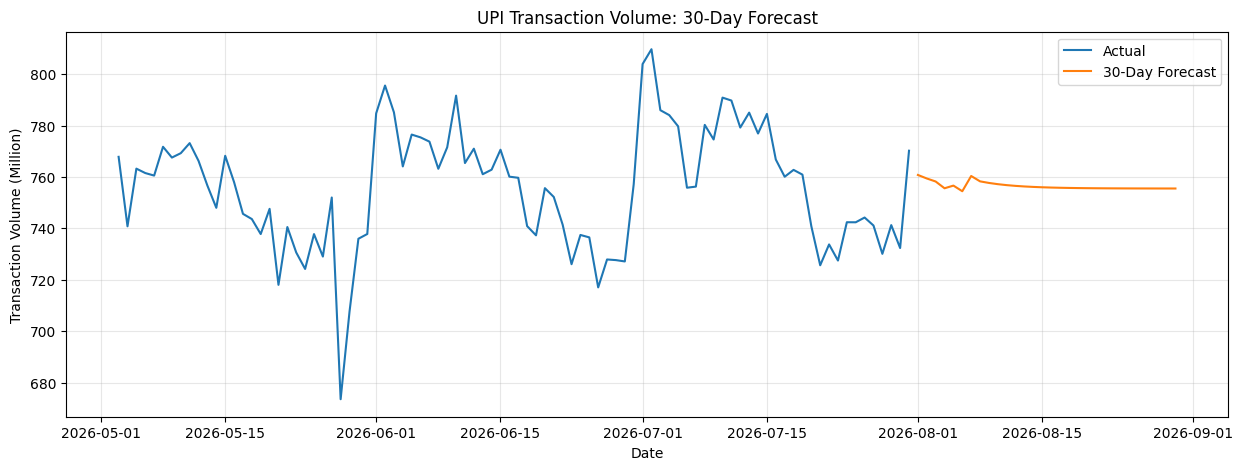

In [278]:
plt.figure(figsize=(15, 5))

# Last 90 days of actual data for context
recent_actual = np.exp(df['Volume_log'].iloc[-90:])

plt.plot(
    recent_actual.index,
    recent_actual,
    label='Actual'
)

plt.plot(
    future_forecast.index,
    future_forecast,
    label='30-Day Forecast'
)

plt.title('UPI Transaction Volume: 30-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Transaction Volume (Million)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

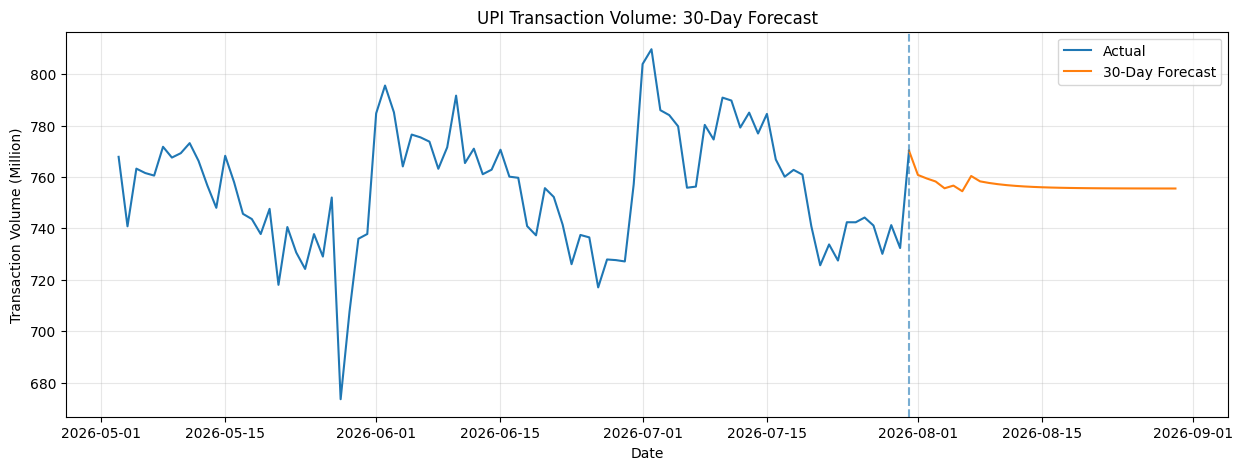

In [236]:
plt.figure(figsize=(15, 5))

recent_actual = np.exp(df['Volume_log'].iloc[-90:])

plt.plot(
    recent_actual.index,
    recent_actual,
    label='Actual'
)

# Connect last actual point to first forecast point
forecast_plot = pd.concat([
    recent_actual.iloc[-1:],
    future_forecast
])

plt.plot(
    forecast_plot.index,
    forecast_plot,
    label='30-Day Forecast'
)

plt.axvline(
    df.index[-1],
    linestyle='--',
    alpha=0.6
)

plt.title('UPI Transaction Volume: 30-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Transaction Volume (Million)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Final Conclusion

- UPI transaction volume showed a strong long-term upward trend with noticeable short-term fluctuations.
- Log transformation and first-order differencing were used to achieve stationarity.
- Both ARIMA and SARIMA models were evaluated using time-series validation and hyperparameter tuning.
- The best model was **SARIMA(1,1,2)(0,0,1,7)**.
- On the untouched 30-day test set, the model achieved:
  - **MAE:** 11.63 million
  - **RMSE:** 15.79 million
  - **MAPE:** 1.53%
- Residual diagnostics showed negligible remaining autocorrelation, supported by Ljung–Box tests.
- The model was then refitted on the complete dataset to generate a 30-day future forecast.3%